Dataset Shape: (109593, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109593 entries, 0 to 109592
Data columns (total 26 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   specialty                    89466 non-null   object 
 1   appointment_time             109593 non-null  int64  
 2   gender                       109593 non-null  object 
 3   no_show                      109593 non-null  object 
 4   disability                   92992 non-null   object 
 5   place                        98054 non-null   object 
 6   appointment_shift            109593 non-null  object 
 7   age                          86633 non-null   float64
 8   under_12_years_old           109593 non-null  int64  
 9   over_60_years_old            109593 non-null  int64  
 10  patient_needs_companion      109593 non-null  int64  
 11  average_temp_day             107382 non-null  float64
 12  average_rain_day             1

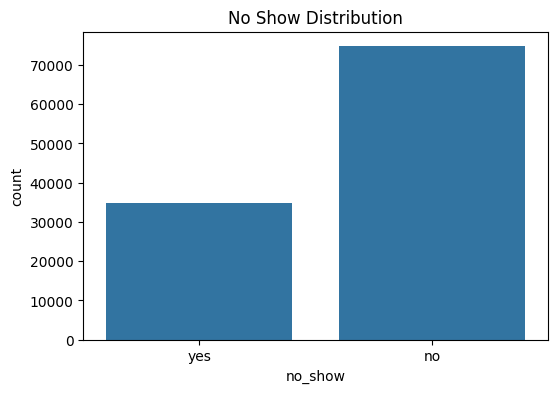

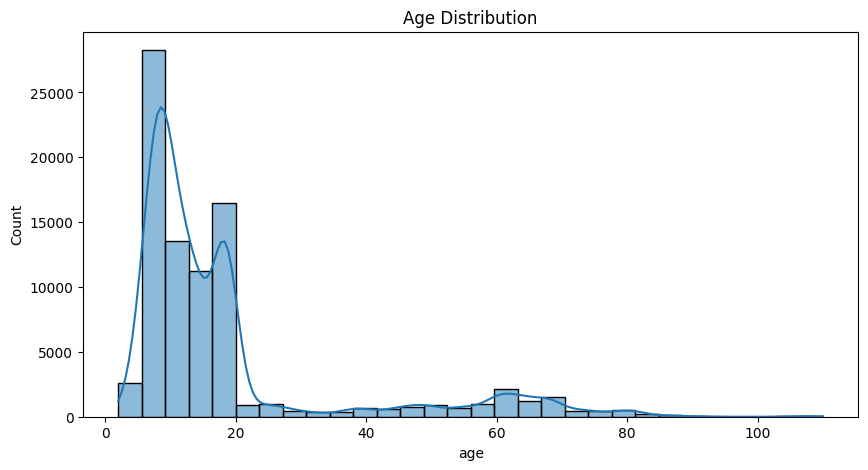

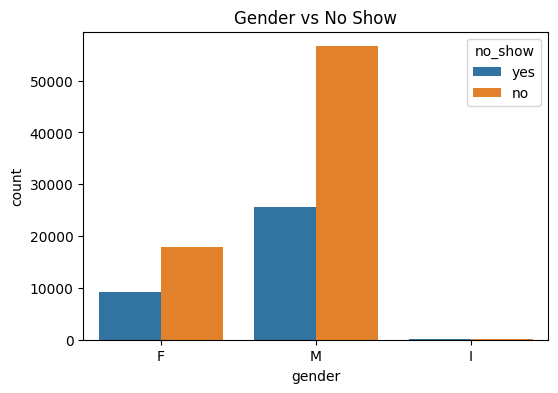

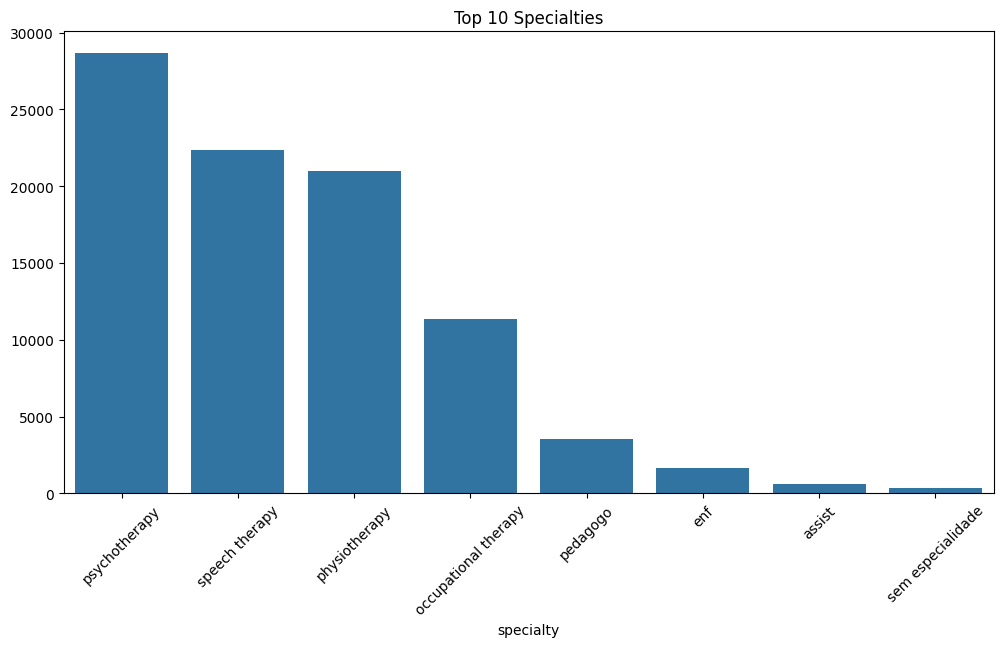

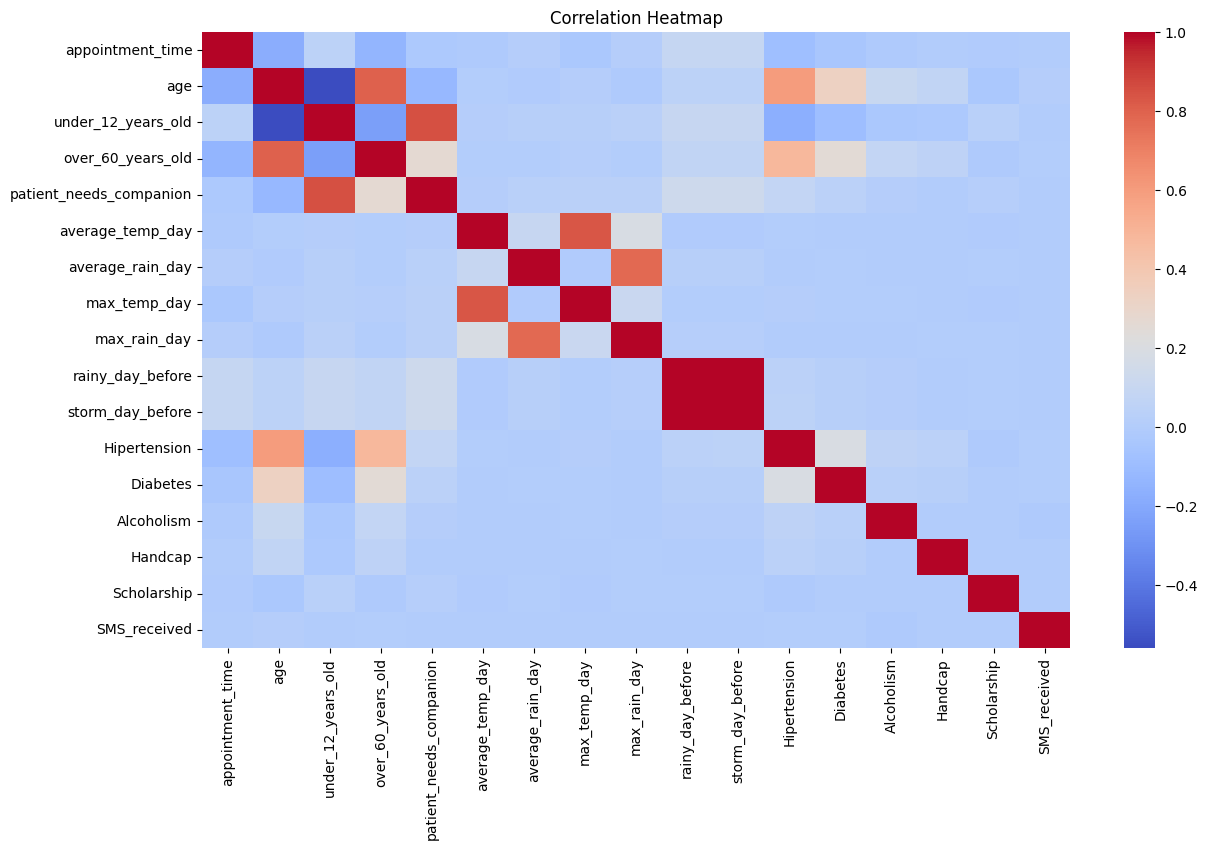

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

# Load dataset
df = pd.read_csv("../data/raw/Medical_appointment_data.csv")

# Display shape
print("Dataset Shape:", df.shape)

# First 5 rows
df.head()

df.info()

missing_values = df.isnull().sum()

missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage
})

missing_df.sort_values(by="Percentage", ascending=False)

print(df["no_show"].value_counts())

print(df["no_show"].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))

sns.countplot(x="no_show", data=df)

plt.title("No Show Distribution")

plt.show()

plt.figure(figsize=(10,5))

sns.histplot(df["age"], bins=30, kde=True)

plt.title("Age Distribution")

plt.show()

plt.figure(figsize=(6,4))

sns.countplot(x="gender", hue="no_show", data=df)

plt.title("Gender vs No Show")

plt.show()

plt.figure(figsize=(12,6))

top_specialties = df["specialty"].value_counts().head(10)

sns.barplot(
    x=top_specialties.index,
    y=top_specialties.values
)

plt.xticks(rotation=45)

plt.title("Top 10 Specialties")

plt.show()

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(14,8))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()